In [1]:
import numpy as np
import pandas as pd
import cooler
from cooltools.lib.numutils import observed_over_expected, adaptive_coarsegrain
from cooltools.lib.numutils import interpolate_bad_singletons, set_diag, interp_nan
from astropy.convolution import Gaussian2DKernel
from astropy.convolution import convolve
from bioframe.io.fileops import read_bigwig

In [2]:
import torch
from pyfaidx import Fasta

In [3]:
FASTA_FILE = "/project/fudenber_735/genomes/mm10/mm10.fa"
BED_FILE = "/project/fudenber_735/tensorflow_models/akita/v2/data/mm10/sequences.bed"
COOL_FILE = "/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.2048.cool"
OUTPUT_DIR = "/scratch1/smaruj/train_pytorch_akita/mouse"
FOLD = 0

# --- Load Data ---
genome = Fasta(FASTA_FILE)
df = pd.read_csv(BED_FILE, sep="\t", header=None, names=["chrom", "start", "end", "fold"])
df_select_fold = df[df["fold"] == f"fold{FOLD}"].reset_index(drop=True)

genome_hic_cool = cooler.Cooler(COOL_FILE)

In [4]:
import random

def one_hot_encode_sequence(sequence_obj):
    sequence = str(sequence_obj).upper()
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    encoded_sequence = np.array([
        base_to_int.get(base, base_to_int[random.choice("ACGT")]) for base in sequence
    ])

    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return np.expand_dims(one_hot_encoded, axis=0)

In [5]:
def process_hic_matrix(genome_hic_cool, mseq_str, diagonal_offset=2, padding=64, kernel_stddev=1):
    seq_hic_raw = genome_hic_cool.matrix(balance=True).fetch(mseq_str)
    
    # Check for NaN filtering percentage
    seq_hic_nan = np.isnan(seq_hic_raw)
    num_filtered_bins = np.sum(np.sum(seq_hic_nan, axis=0) == len(seq_hic_nan))
    print("num_filtered_bins:", num_filtered_bins)
    
    if num_filtered_bins > (0.5 * len(seq_hic_nan)):
        print(f"More than 50% bins filtered in {mseq_str}. Check Hi-C data quality.")
        
    # clip first diagonals and high values
    clipval = np.nanmedian(np.diag(seq_hic_raw, diagonal_offset))
    for i in range(-diagonal_offset+1, diagonal_offset):
        set_diag(seq_hic_raw, clipval, i)
    seq_hic_raw = np.clip(seq_hic_raw, 0, clipval)
    seq_hic_raw[seq_hic_nan] = np.nan
    
    # adaptively coarsegrain based on raw counts
    seq_hic_smoothed = adaptive_coarsegrain(
                            seq_hic_raw,
                            genome_hic_cool.matrix(balance=False).fetch(mseq_str),
                            cutoff=2, max_levels=8)
    seq_hic_nan = np.isnan(seq_hic_smoothed)
    
    # local obs/exp
    seq_hic_obsexp = observed_over_expected(seq_hic_smoothed, ~seq_hic_nan)[0]
    
    log_hic_obsexp = np.log(seq_hic_obsexp)
    
    # Apply padding
    if padding > 0:
        log_hic_obsexp = log_hic_obsexp[padding:-padding, padding:-padding]
    
    log_hic_obsexp = interp_nan(log_hic_obsexp)
    for i in range(-diagonal_offset+1, diagonal_offset): set_diag(log_hic_obsexp, 0,i)
    
    kernel = Gaussian2DKernel(x_stddev=kernel_stddev)
    seq_hic = convolve(log_hic_obsexp, kernel)
    
    return seq_hic    

In [6]:
def upper_triangular_to_vector_skip_diagonals(matrix, dim=512, diag=2):
    
    # Extract the upper triangular part excluding the first two diagonals
    upper_triangular_vector = matrix[np.triu_indices(dim, k=diag)]
    
    return upper_triangular_vector

In [7]:
N = 256
diagonal_offset = 2

In [8]:
orca_out_dir = "/scratch1/smaruj/orca_validation/fold0_orca_preds"

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()

In [11]:
import torch.nn.functional as F

In [12]:
N = 256
diagonal_offset = 2

In [13]:
def vector_to_symmetric_matrix(vec, N):
    matrix = torch.zeros((N, N), dtype=vec.dtype)
    triu_indices = torch.triu_indices(N, N)
    matrix[triu_indices[0], triu_indices[1]] = vec
    matrix = matrix + matrix.T - torch.diag(torch.diag(matrix))
    return matrix

In [14]:
import scipy.stats

In [15]:
# Exclude diagonals: 0 and ±1
def get_upper_tri_mask(n, skip_diagonals=2):
    # Create mask with False on excluded diagonals, True elsewhere in upper triangle
    mask = np.triu(np.ones((n, n), dtype=bool), k=skip_diagonals)
    return mask

index: 0
num_filtered_bins: 20


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


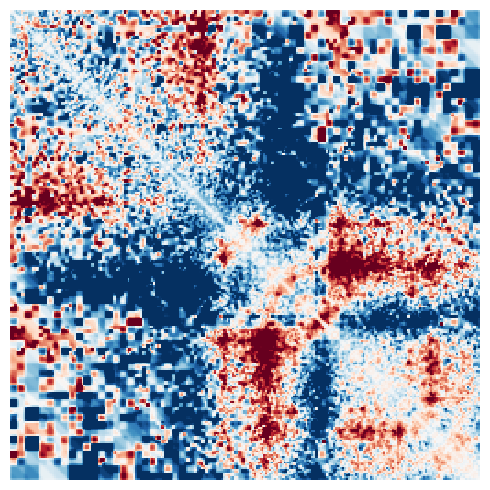

/tmp/SLURM_1349767/ipykernel_2120259/977892694.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  orca_vec = torch.load(file_path)


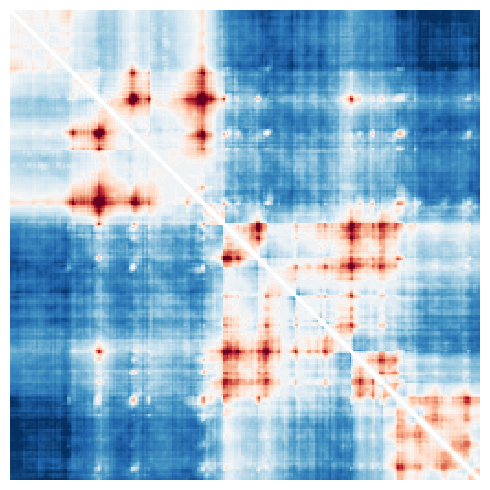

index: 1
num_filtered_bins: 14


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


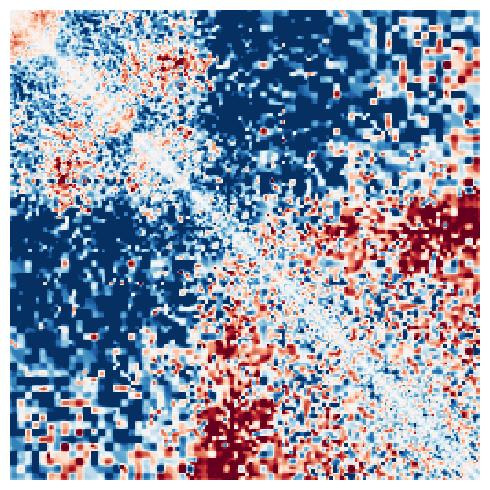

/tmp/SLURM_1349767/ipykernel_2120259/977892694.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  orca_vec = torch.load(file_path)


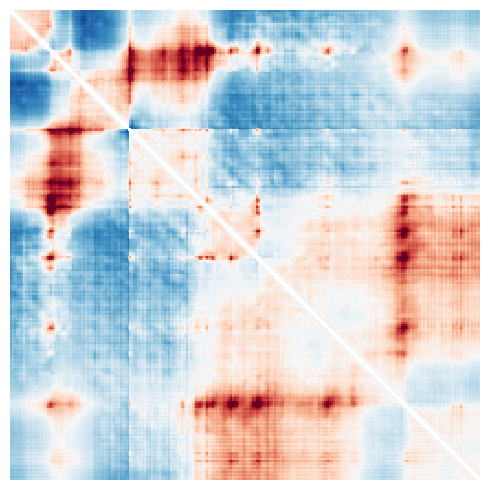

index: 2
num_filtered_bins: 10


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


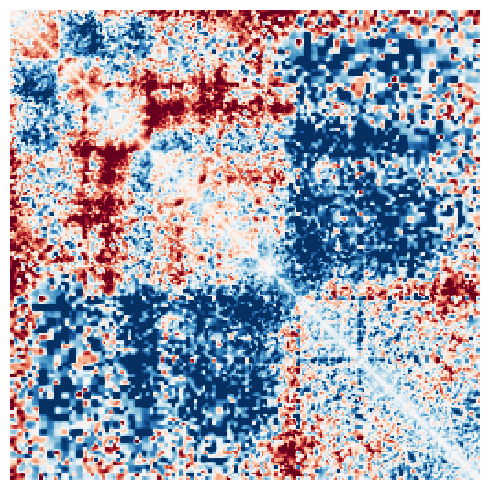

/tmp/SLURM_1349767/ipykernel_2120259/977892694.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  orca_vec = torch.load(file_path)


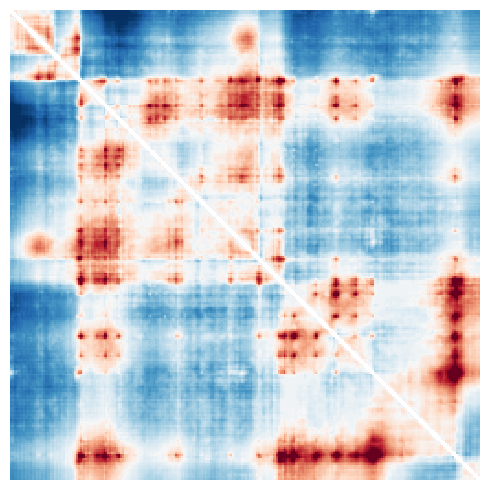

In [16]:
pearson_r = []

for i, row in enumerate(df_select_fold[:3].itertuples(index=False)):
    print("index:", i)
    chrom, start, end = row.chrom, row.start, row.end
    mseq_str = f"{chrom}:{start}-{end}"
    
    # TARGET
    sequence = genome[chrom][start:end]
    ohe_sequence = one_hot_encode_sequence(sequence)
    matrix = process_hic_matrix(genome_hic_cool, mseq_str, diagonal_offset=2, padding=64, kernel_stddev=1)
    
    # pooling 
    matrix = torch.tensor(matrix, dtype=torch.float32)
    matrix = matrix.unsqueeze(0)

    # Apply 2x2 average pooling
    matrix_pooled = F.avg_pool2d(matrix, kernel_size=2)  # -> (batch, 1, 256, 256)

    # Remove the channel dimension if not needed
    matrix_pooled = matrix_pooled.squeeze(0)  # -> (batch, 256, 256)
    matrix_pooled = matrix_pooled.numpy()
    
    plot_map(matrix_pooled)
    
    # ORCA'S PRED
    filename = f"{chrom}_{start}_{end}_orca_pred.pt"
    file_path = f"{orca_out_dir}/{filename}"
    
    orca_vec = torch.load(file_path)
    orca_matrix = vector_to_symmetric_matrix(orca_vec, N).cpu().numpy()
    
    for i in range(-1, 2):
        diag_indices = np.diag_indices_from(orca_matrix)
        if i < 0:
            orca_matrix[diag_indices[0][:i], diag_indices[1][-i:]] = np.nan
        elif i > 0:
            orca_matrix[diag_indices[0][i:], diag_indices[1][:-i]] = np.nan
        else:
            orca_matrix[diag_indices] = np.nan
    
    plot_map(orca_matrix)
    
    mask = get_upper_tri_mask(matrix_pooled.shape[0])
    target_vec = matrix_pooled[mask]
    orca_vec = orca_matrix[mask]
    
    # Remove NaNs (e.g., from diagonals)
    valid_mask = ~np.isnan(target_vec) & ~np.isnan(orca_vec)
    target_vec = target_vec[valid_mask]
    orca_vec = orca_vec[valid_mask]
    
    r, p_value = scipy.stats.pearsonr(target_vec, orca_vec)
    # print("PearsonR=", r)
    pearson_r.append(r)

In [ ]:
average_r = sum(pearson_r) / len(pearson_r)
print(f"Average Pearson R: {average_r:.4f}")

In [ ]:
len(pearson_r)